# 04 — Analiza statystyczna metryk z `appendix/A_metrics/`

**Cel.** Powtórzenie kluczowych testów statystycznych użytych w pracy
magisterskiej na lokalnych kopiach metryk z katalogu
`appendix/A_metrics/`. Zachowujemy ten sam zestaw metryk M1–M13
(zob. `appendix/INDEX.md`), te same testy (Friedman + Nemenyi,
Vargha–Delaney A12, Wilson 95% CI) oraz ten sam podział per środowisko.

**Co i jak edytować?**

* `METRICS_TO_ANALYZE` — lista par `(kolumna_w_CSV, kierunek)`.
  Kierunek `'min'` = niżej lepiej, `'max'` = wyżej lepiej.
* `ENVIRONMENTS` — które środowiska analizować (`'forest'`, `'urban'`).
* `ALPHA` — poziom istotności (domyślnie `0.05`).

**Odniesienia.** Friedman test (Friedman 1937; Demšar 2006);
post-hoc Nemenyi (Nemenyi 1963); A12 effect size (Vargha & Delaney 2000);
Wilson 95% CI (Wilson 1927; Newcombe 1998).

In [13]:
import prepare_notebook  # noqa: F401

In [14]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare

# ---------------------------------------------------------------------------
# PARAMETRY
# ---------------------------------------------------------------------------
ENVIRONMENTS = ["forest", "urban"]
ALPHA = 0.05

# (kolumna w `run_metrics_subset.csv`, kierunek, etykieta z `INDEX.md`).
# Dyrektywa kierunku: 'min' ⇒ wartość najniższa = najlepsza; 'max' ⇒ odwrotnie.
METRICS_TO_ANALYZE = [
    ("final_objective_f1_trajectory", "min", "M2 — Długość trajektorii (F1)"),
    ("final_objective",                 "min", "M9 — Wartość optymalizacji offline"),
    ("mean_evasion_arc_length_m",       "min", "M6 — Długość krzywej unikowej"),
    ("rejoin_quality",                  "min", "M7 — Skuteczność powrotu na trajektorię"),
    ("mean_online_best_fitness",        "min", "M11 — Wartość optymalizacji online"),
    ("online_sp1",                      "min", "M13 — SP1 online"),
]

PROJECT_ROOT = Path(prepare_notebook.project_root)
APPENDIX = PROJECT_ROOT / "appendix" / "A_metrics"
assert APPENDIX.exists(), APPENDIX

In [15]:
# Wczytanie subsetów dostarczonych w `appendix/A_metrics/`.
runs = pd.read_csv(APPENDIX / "run_metrics_subset.csv")
iters = pd.read_csv(APPENDIX / "iteration_metrics_subset.csv")
online_conv = pd.read_csv(APPENDIX / "online_convergence_subset.csv")

# Derived M1 (F3+F5) i M4 (swarm cohesion deviation z dwóch agregatów).
runs["trajectory_safety_f3_f5"] = runs["total_threat_cost"] + runs["total_coordination_cost"]
runs["swarm_cohesion_deviation"] = (
    (runs["min_inter_uav_distance_m"] - 5.0).abs()
    + (runs["max_inter_uav_distance_m"] - 5.0).abs()
)
METRICS_TO_ANALYZE.append(("trajectory_safety_f3_f5", "min", "M1 — Bezpieczeństwo trajektorii (F3+F5)"))
METRICS_TO_ANALYZE.append(("swarm_cohesion_deviation", "min", "M4 — Spójność roju"))

print(f"Runs:  {runs.shape}")
print(f"Iters: {iters.shape}")
print(f"Online conv: {online_conv.shape}")
print("Algorytmy:", sorted(runs['optimizer_algo'].unique()))
print("Środowiska:", sorted(runs['environment'].unique()))

Runs:  (240, 18)
Iters: (60000, 5)
Online conv: (16838, 5)
Algorytmy: ['msffoa', 'nsga-3', 'ooa', 'ssa']
Środowiska: ['forest', 'urban']


In [16]:
# Tabela statystyk opisowych — odpowiednik `B_statistical_tests/summary/*`.
def descriptive_table(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """n / mean / std / median / min / max / IQR per (env, optimizer)."""
    g = df.groupby(["environment", "optimizer_algo"])[metric]
    out = g.agg([("n", "count"), ("mean", "mean"), ("std", "std"),
                  ("min", "min"), ("q25", lambda s: s.quantile(0.25)),
                  ("median", "median"), ("q75", lambda s: s.quantile(0.75)),
                  ("max", "max")]).round(4)
    return out

for col, _direction, label in METRICS_TO_ANALYZE[:3]:
    print("=" * 80)
    print(label)
    display(descriptive_table(runs, col))

M2 — Długość trajektorii (F1)


n       mean       std        min        q25  \
environment optimizer_algo                                                  
forest      msffoa          30  3081.9010   33.2507  3015.8597  3060.5340   
            nsga-3          30  2978.0697   14.4039  2955.8312  2968.1525   
            ooa             30  3178.7652  138.1723  3034.9980  3095.9257   
            ssa             30  3249.8992   59.9928  3148.8773  3216.8176   
urban       msffoa          30  5188.7504   52.5131  5102.6709  5151.1749   
            nsga-3          30  4963.4265   12.5425  4955.3537  4957.8983   
            ooa             30  5211.5064  132.1180  5043.3847  5087.8845   
            ssa             30  5379.1334  125.2226  5169.6188  5295.0668   

                               median        q75        max  
environment optimizer_algo                                   
forest      msffoa          3081.9297  3097.0216  3157.8558  
            nsga-3          2973.8870  2987.0953  3007.6716  
            ooa             3132.1800  3223.9021  3759.9470  
            ssa             3248.5637  3280.8809  3439.4771  
urban       msffoa          5171.3468  5227.8931  5301.9274  
            nsga-3          4959.8013  4961.9390  5017.3230  
            ooa             5200.7788  5305.5336  5610.4862  
            ssa             5358.6146  5429.4719  5788.0884

M9 — Wartość optymalizacji offline


n     mean      std     min      q25   median  \
environment optimizer_algo                                                   
forest      msffoa          30   0.9746   0.3733  0.5908   0.7135   0.8496   
            nsga-3          30   0.6494   0.4839  0.2026   0.3731   0.5093   
            ooa             30  19.1777  26.1916  0.7976   6.6567   9.1302   
            ssa             30  26.1873  10.6625  5.0504  20.0012  29.2845   
urban       msffoa          30   1.7274   0.8426  1.3004   1.3959   1.4998   
            nsga-3          30   0.4415   0.4135  0.2532   0.2808   0.3109   
            ooa             30  22.8441  27.6198  0.8666   3.5221  14.3962   
            ssa             30  15.3786  29.5635  1.3679   2.8592   3.8070   

                                q75       max  
environment optimizer_algo                     
forest      msffoa           1.1380    2.1103  
            nsga-3           0.8811    2.7181  
            ooa             22.6831  133.5773  
            ssa             33.5285   43.8170  
urban       msffoa           1.6110    5.0279  
            nsga-3           0.3473    2.0018  
            ooa             30.9443  135.4104  
            ssa              7.3716  124.0945

M6 — Długość krzywej unikowej


n     mean     std      min      q25   median  \
environment optimizer_algo                                                   
forest      msffoa          30  23.2545  2.4590  17.8743  20.7111  25.0641   
            nsga-3          30  24.7282  0.3802  23.8252  24.4478  25.0226   
            ooa             29  23.4482  2.0445  19.1145  21.6226  24.1397   
            ssa             30  23.0898  2.2346  18.9251  20.7410  24.3105   
urban       msffoa          30  22.6765  2.1684  19.2540  20.7332  22.5891   
            nsga-3          30  24.9091  0.2794  24.4292  24.6166  25.0607   
            ooa             30  22.9276  2.6817  17.9105  20.7468  25.0234   
            ssa             30  22.4527  2.7158  17.4914  20.2114  24.2667   

                                q75      max  
environment optimizer_algo                    
forest      msffoa          25.0897  25.1239  
            nsga-3          25.0521  25.0805  
            ooa             25.0802  25.1382  
            ssa             25.0773  25.2531  
urban       msffoa          25.0748  25.1805  
            nsga-3          25.0789  25.1076  
            ooa             25.0921  25.1248  
            ssa             25.0540  25.1258

In [17]:
# Test Friedmana + krytyczna różnica Nemenyiego.
from scipy.stats import rankdata

_NEMENYI_Q_ALPHA_05_K4 = 2.569  # k=4 algorytmy, α=0.05 (Demšar 2006, Tabela 5a)

def friedman_with_ranks(df: pd.DataFrame, metric: str, direction: str = "min",
                         env: str | None = None) -> dict:
    """Zwraca {'statistic','p_value','ranks','cd','n_datasets','k'}.

    Friedman test wymaga zbiorów spójnych po `seed`. Wartości NaN są
    odrzucane jako blok. Wektor `ranks` odpowiada średniej randze
    optymalizatora (im niższa, tym lepiej dla `direction='min'`).
    """
    sub = df.copy()
    if env is not None:
        sub = sub[sub["environment"] == env]
    pivot = sub.pivot_table(index="seed", columns="optimizer_algo", values=metric)
    pivot = pivot.dropna(how="any")
    if pivot.empty or pivot.shape[1] < 3:
        return {"statistic": np.nan, "p_value": np.nan, "ranks": {},
                "cd": np.nan, "n_datasets": 0, "k": pivot.shape[1]}
    k = pivot.shape[1]
    n_datasets = pivot.shape[0]

    # Ranks per-block: w `direction='max'` odwracamy znak.
    sign = -1.0 if direction == "max" else 1.0
    block_ranks = np.apply_along_axis(rankdata, 1, sign * pivot.to_numpy())
    avg_ranks = pd.Series(block_ranks.mean(axis=0), index=pivot.columns)

    stat, p = friedmanchisquare(*[pivot[c].to_numpy() for c in pivot.columns])
    cd = _NEMENYI_Q_ALPHA_05_K4 * np.sqrt(k * (k + 1) / (6 * n_datasets))
    return {"statistic": float(stat), "p_value": float(p),
             "ranks": avg_ranks.to_dict(), "cd": float(cd),
             "n_datasets": int(n_datasets), "k": int(k)}

rows = []
for col, direction, label in METRICS_TO_ANALYZE:
    for env in ENVIRONMENTS:
        res = friedman_with_ranks(runs, col, direction=direction, env=env)
        rows.append({"metric": label, "environment": env,
                       "statistic": res["statistic"], "p_value": res["p_value"],
                       "CD_nemenyi": res["cd"], "n": res["n_datasets"],
                       **{f"rank[{a}]": v for a, v in res["ranks"].items()}})
friedman_df = pd.DataFrame(rows)
display(friedman_df.round(4))

,metric,environment,statistic,p_value,CD_nemenyi,n,rank[msffoa],rank[nsga-3],rank[ooa],rank[ssa]
0,M2 — Długość trajektorii (F1),forest,82.1200,0.0000,0.8563,30,2.1000,1.0000,3.0333,3.8667
1,M2 — Długość trajektorii (F1),urban,73.0000,0.0000,0.8563,30,2.5000,1.0000,2.6667,3.8333
2,M9 — Wartość optymalizacji offline,forest,79.2400,0.0000,0.8563,30,1.8333,1.1667,3.2000,3.8000
3,M9 — Wartość optymalizacji offline,urban,66.2800,0.0000,0.8563,30,2.2000,1.0667,3.5000,3.2333
4,M6 — Długość krzywej unikowej,forest,0.6000,0.8964,0.8710,29,2.6552,2.4828,2.4138,2.4483
5,M6 — Długość krzywej unikowej,urban,14.5600,0.0022,0.8563,30,2.4333,3.1667,2.5000,1.9000
6,M7 — Skuteczność powrotu na trajektorię,forest,4.1586,0.2448,0.8710,29,2.7931,2.2414,2.2759,2.6897
7,M7 — Skuteczność powrotu na trajektorię,urban,8.4621,0.0374,0.8710,29,2.8966,2.1034,2.2069,2.7931
8,M11 — Wartość optymalizacji online,forest,24.8897,0.0000,0.8710,29,3.3448,2.6552,2.3103,1.6897
9,M11 — Wartość optymalizacji online,urban,18.3600,0.0004,0.8563,30,3.3333,2.4333,2.0000,2.2333


In [18]:
# Vargha–Delaney A12 (Vargha & Delaney 2000) — interpretacja:
#   |A12 - 0.5| < 0.06  → trivial
#   |A12 - 0.5| < 0.14  → small
#   |A12 - 0.5| < 0.21  → medium
#   inaczej             → large
def a12(x: np.ndarray, y: np.ndarray) -> float:
    """P(X > Y) + 0.5·P(X = Y); minimalistyczna, czytelna implementacja."""
    x = np.asarray(x); y = np.asarray(y)
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return np.nan
    n_gt = sum(1 for xi in x for yj in y if xi > yj)
    n_eq = sum(1 for xi in x for yj in y if xi == yj)
    return (n_gt + 0.5 * n_eq) / (nx * ny)

def a12_magnitude(a: float) -> str:
    if np.isnan(a):
        return "n/a"
    d = abs(a - 0.5)
    if d < 0.06: return "negligible"
    if d < 0.14: return "small"
    if d < 0.21: return "medium"
    return "large"

pairwise_rows = []
for col, direction, label in METRICS_TO_ANALYZE:
    for env in ENVIRONMENTS:
        sub = runs[runs["environment"] == env]
        algos = sorted(sub["optimizer_algo"].unique())
        for a, b in combinations(algos, 2):
            x = sub.loc[sub["optimizer_algo"] == a, col].to_numpy()
            y = sub.loc[sub["optimizer_algo"] == b, col].to_numpy()
            # Dla 'max' kierunku interpretacja A12 jest odwrotna — odwracamy
            # wartości tak, by '0.5 < A12' zawsze oznaczało "a lepszy niż b".
            if direction == "max":
                x, y = -x, -y
            val = 1.0 - a12(x, y)   # P(x < y) — niższe = lepsze
            pairwise_rows.append({"metric": label, "environment": env,
                                    "alg_a": a, "alg_b": b,
                                    "a12_a_better": round(val, 4),
                                    "magnitude": a12_magnitude(val)})
a12_df = pd.DataFrame(pairwise_rows)
display(a12_df.head(20))

,metric,environment,alg_a,alg_b,a12_a_better,magnitude
0,M2 — Długość trajektorii (F1),forest,msffoa,nsga-3,0.0000,large
1,M2 — Długość trajektorii (F1),forest,msffoa,ooa,0.7944,large
2,M2 — Długość trajektorii (F1),forest,msffoa,ssa,0.9989,large
3,M2 — Długość trajektorii (F1),forest,nsga-3,ooa,1.0000,large
4,M2 — Długość trajektorii (F1),forest,nsga-3,ssa,1.0000,large
5,M2 — Długość trajektorii (F1),forest,ooa,ssa,0.7811,large
6,M2 — Długość trajektorii (F1),urban,msffoa,nsga-3,0.0000,large
7,M2 — Długość trajektorii (F1),urban,msffoa,ooa,0.5133,negligible
8,M2 — Długość trajektorii (F1),urban,msffoa,ssa,0.9522,large
9,M2 — Długość trajektorii (F1),urban,nsga-3,ooa,1.0000,large


In [19]:
# Wilson 95% CI dla offline failure_rate (potrzebny `tracking_phase_collisions`
# nie jest w subsetcie — używamy bezpośrednio wartości z `appendix/B_statistical_tests/wilson/`).
WILSON_DIR = PROJECT_ROOT / "appendix" / "B_statistical_tests" / "wilson"
if (WILSON_DIR / "evasion_success_rate.csv").exists():
    wilson = pd.read_csv(WILSON_DIR / "evasion_success_rate.csv")
    print("Evasion success rate (Wilson 95% CI):")
    display(wilson)

# Niezależnie wyliczamy 95% CI z definicji Wilsona dla kontroli.
def wilson_ci(n_success: int, n_total: int, z: float = 1.96) -> tuple[float, float, float]:
    if n_total == 0:
        return (np.nan, np.nan, np.nan)
    p = n_success / n_total
    denom = 1 + z**2 / n_total
    centre = (p + z**2 / (2 * n_total)) / denom
    half = z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / denom
    return (p, max(0.0, centre - half), min(1.0, centre + half))

print("\nSanity-check Wilson 95% CI (5 sukcesów na 30 prób):", wilson_ci(5, 30))

Evasion success rate (Wilson 95% CI):


,environment,optimizer,n_runs,n_successes,success_rate,wilson_ci95_low,wilson_ci95_high
0,forest,msffoa,30,29,0.966667,0.833296,0.994091
1,forest,nsga-3,30,30,1.000000,0.886487,1.000000
2,forest,ooa,30,20,0.666667,0.487801,0.807695
3,forest,ssa,30,23,0.766667,0.590717,0.882076
4,urban,msffoa,30,30,1.000000,0.886487,1.000000
5,urban,nsga-3,30,30,1.000000,0.886487,1.000000
6,urban,ooa,30,27,0.900000,0.743789,0.965400
7,urban,ssa,30,27,0.900000,0.743789,0.965400



Sanity-check Wilson 95% CI (5 sukcesów na 30 prób): (0.16666666666666666, 0.07336434240351683, 0.33564705185680177)


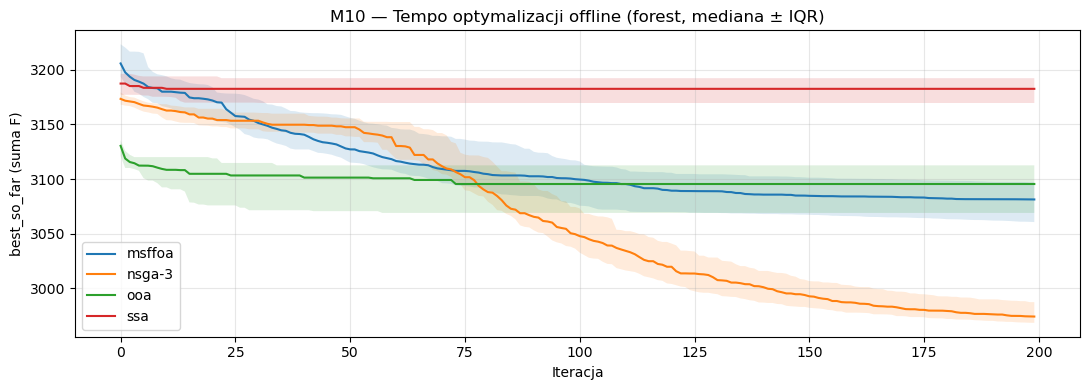

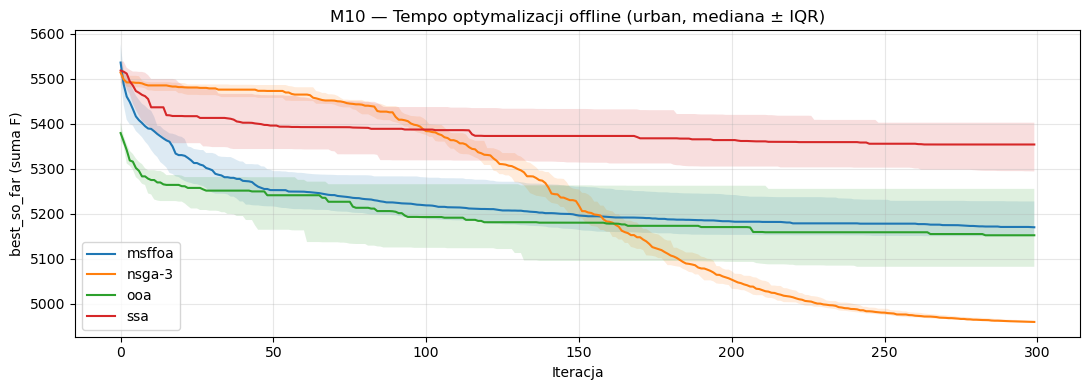

In [20]:
# Krzywe zbieżności offline (M10) — mediana ± IQR per generacja.
def plot_offline_convergence(iters_df: pd.DataFrame, runs_df: pd.DataFrame, env: str):
    # Joinujemy z runs na (run_id) by przefiltrować po środowisku/optymalizatorze.
    merged = iters_df.merge(
        runs_df[["run_id", "environment", "optimizer_algo"]],
        on="run_id", how="inner"
    )
    merged = merged[merged["environment"] == env]
    fig, ax = plt.subplots(figsize=(11, 4))
    for algo, g in merged.groupby("optimizer_algo"):
        per_gen = g.groupby("iteration")["best_so_far"].quantile([0.25, 0.5, 0.75]).unstack()
        ax.plot(per_gen.index, per_gen[0.5], label=algo, linewidth=1.5)
        ax.fill_between(per_gen.index, per_gen[0.25], per_gen[0.75], alpha=0.15)
    ax.set_xlabel("Iteracja"); ax.set_ylabel("best_so_far (suma F)")
    ax.set_title(f"M10 — Tempo optymalizacji offline ({env}, mediana ± IQR)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

for env in ENVIRONMENTS:
    plot_offline_convergence(iters, runs, env)

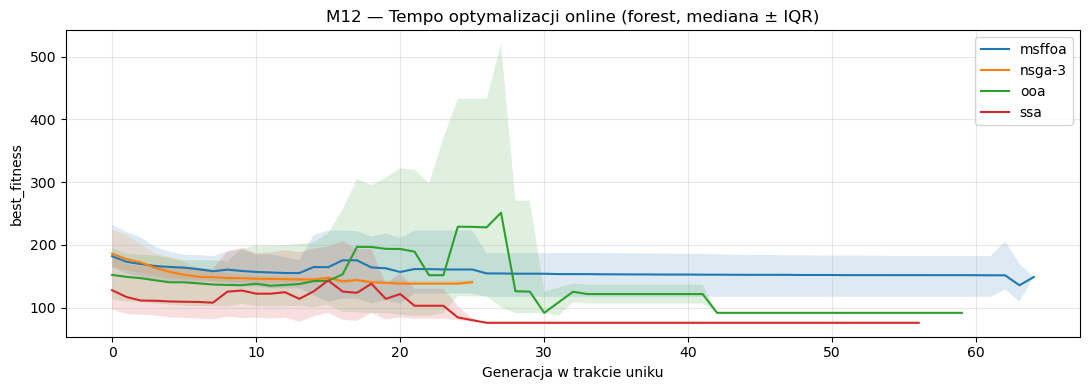

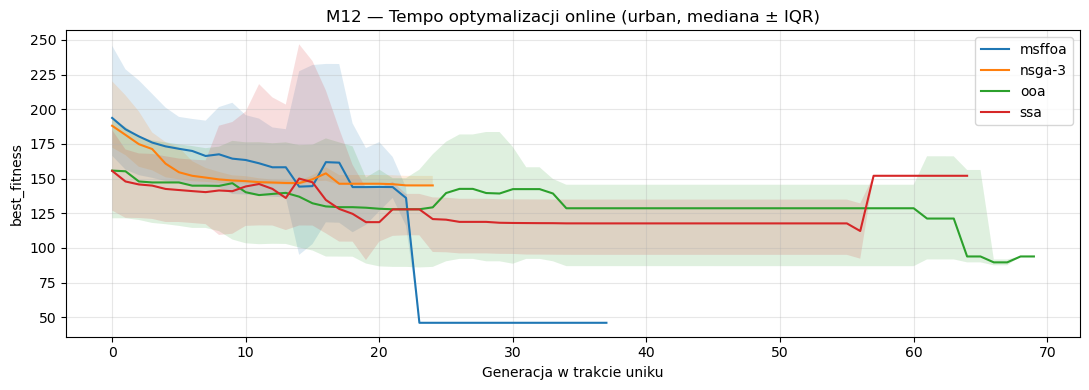

In [21]:
# Krzywe zbieżności online (M12) — agregat po wszystkich trygerach.
def plot_online_convergence(conv_df: pd.DataFrame, runs_df: pd.DataFrame, env: str):
    merged = conv_df.merge(
        runs_df[["run_id", "environment", "optimizer_algo"]],
        on="run_id", how="inner"
    )
    merged = merged[merged["environment"] == env]
    if merged.empty:
        print(f"[INFO] Brak online-convergence danych dla {env}")
        return
    fig, ax = plt.subplots(figsize=(11, 4))
    for algo, g in merged.groupby("optimizer_algo"):
        per_gen = g.groupby("generation")["best_fitness"].quantile([0.25, 0.5, 0.75]).unstack()
        ax.plot(per_gen.index, per_gen[0.5], label=algo, linewidth=1.5)
        ax.fill_between(per_gen.index, per_gen[0.25], per_gen[0.75], alpha=0.15)
    ax.set_xlabel("Generacja w trakcie uniku"); ax.set_ylabel("best_fitness")
    ax.set_title(f"M12 — Tempo optymalizacji online ({env}, mediana ± IQR)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

for env in ENVIRONMENTS:
    plot_online_convergence(online_conv, runs, env)

/tmp/ipykernel_41905/1692042243.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=algos, showmeans=True, meanline=True)
/tmp/ipykernel_41905/1692042243.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=algos, showmeans=True, meanline=True)
/tmp/ipykernel_41905/1692042243.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=algos, showmeans=True, meanline=True)
/tmp/ipykernel_41905/1692042243.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name w

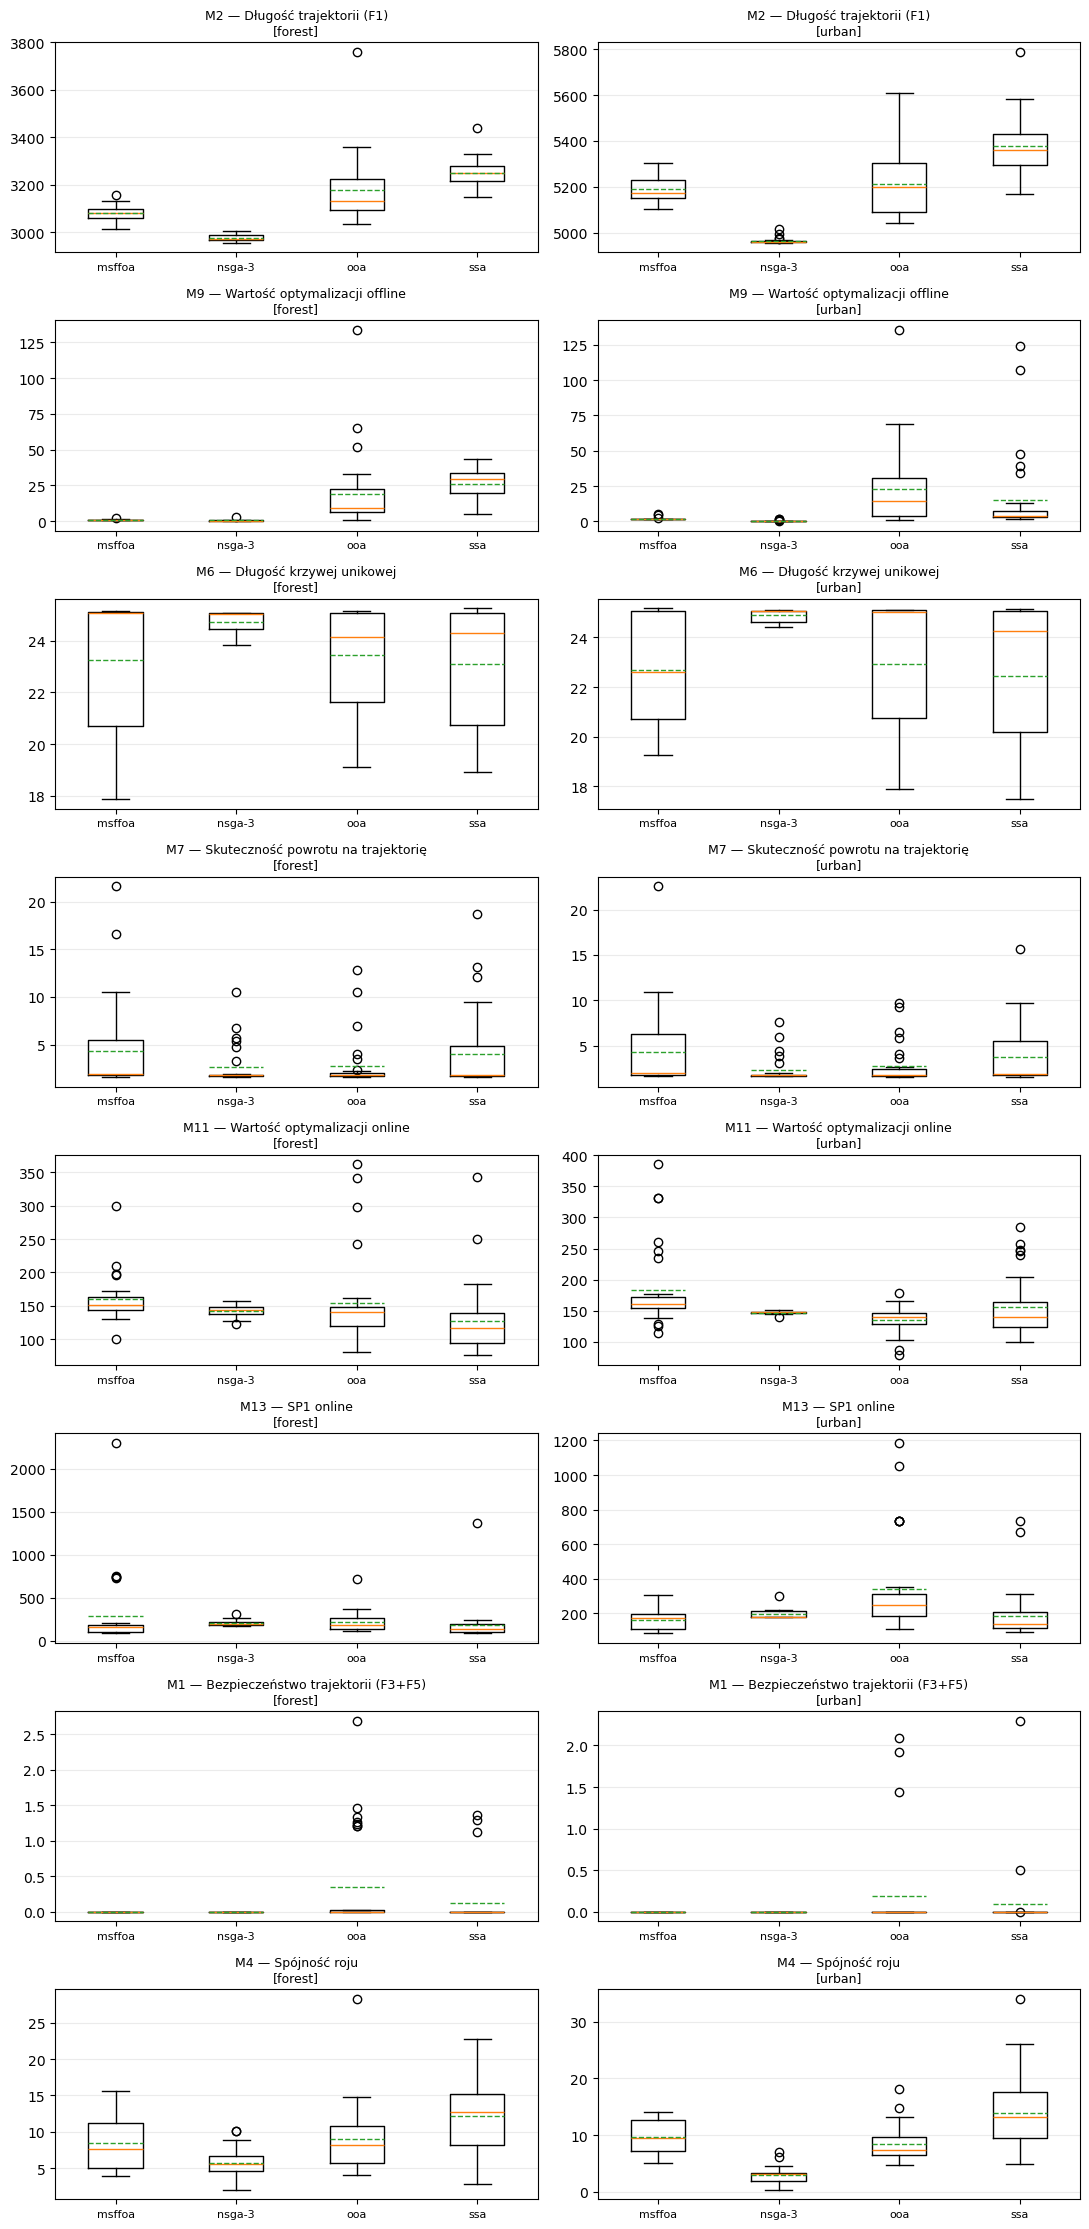

In [10]:
# Boxploty — szybki overview rozkładu wartości metryk per (env, optimizer).
fig, axes = plt.subplots(len(METRICS_TO_ANALYZE), len(ENVIRONMENTS),
                          figsize=(11, 2.8 * len(METRICS_TO_ANALYZE)))
if axes.ndim == 1:
    axes = axes[None, :]
for i, (col, _direction, label) in enumerate(METRICS_TO_ANALYZE):
    for j, env in enumerate(ENVIRONMENTS):
        ax = axes[i, j]
        sub = runs[runs["environment"] == env]
        algos = sorted(sub["optimizer_algo"].unique())
        data = [sub.loc[sub["optimizer_algo"] == a, col].dropna() for a in algos]
        ax.boxplot(data, labels=algos, showmeans=True, meanline=True)
        ax.set_title(f"{label}\n[{env}]", fontsize=9)
        ax.tick_params(axis='x', labelsize=8)
        ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

## Metryki niedostępne w subsecie `A_metrics/`

Dwie metryki z `INDEX.md` (M3 — gładkość F2+F4, M5 — odsetek trajektorii
kolizyjnych offline) wymagają kolumn, których nie ma w
`run_metrics_subset.csv` (`F[1]` ⇒ `final_objective_f2_height_angle`
i `tracking_phase_collisions`). Wczytujemy zatem gotowe agregaty
wygenerowane na pełnej `analysis.db` — pliki znajdują się w
`appendix/B_statistical_tests/`.

In [11]:
STATS_DIR = PROJECT_ROOT / "appendix" / "B_statistical_tests"

# M3 — gładkość trajektorii (F2+F4): statystyki opisowe + Friedman + A12.
print("=" * 80, "\nM3 — Gładkość trajektorii (F2+F4)")
display(pd.read_csv(STATS_DIR / "summary" / "summary_trajectory_smoothness_f2_f4.csv"))
for env in ENVIRONMENTS:
    print(f"--- Friedman {env} ---")
    display(pd.read_csv(STATS_DIR / "friedman" / f"{env}_friedman_trajectory_smoothness_f2_f4.csv"))
    print(f"--- A12 {env} ---")
    display(pd.read_csv(STATS_DIR / "a12" / f"{env}_a12_trajectory_smoothness_f2_f4.csv"))

M3 — Gładkość trajektorii (F2+F4)


,environment,optimizer,n,mean,std,min,max,median,q25,q75,low_power_warning
0,forest,msffoa,30,104.769546,6.164568,91.812698,123.101087,104.528924,101.067361,108.805336,False
1,forest,nsga-3,30,28.918774,2.948740,25.256113,36.322863,28.504870,26.452306,30.957381,False
2,forest,ooa,30,89.933040,25.603199,34.599262,134.862413,93.781914,77.436833,106.498884,False
3,forest,ssa,30,100.440828,21.341718,61.022002,157.128027,99.970727,93.429408,108.693484,False
4,urban,msffoa,30,338.150385,8.834920,321.583543,362.436605,337.482327,332.671184,342.637673,False
5,urban,nsga-3,30,64.579294,5.408554,55.907090,76.171051,63.852207,60.658336,67.869354,False
6,urban,ooa,30,110.880360,52.055762,69.133617,310.644710,94.920468,77.522082,111.178477,False
7,urban,ssa,30,192.056033,48.408814,130.687834,315.692703,179.472932,161.404423,201.359358,False


--- Friedman forest ---


,optimizer,avg_rank,statistic,p_value,cd_nemenyi,n_datasets
0,msffoa,3.366667,58.12,0.0,0.856333,30
1,nsga-3,1.000000,58.12,0.0,0.856333,30
2,ooa,2.700000,58.12,0.0,0.856333,30
3,ssa,2.933333,58.12,0.0,0.856333,30


--- A12 forest ---


,alg_a,alg_b,a12,magnitude
0,msffoa,nsga-3,0.000000,large
1,msffoa,ooa,0.297778,medium
2,msffoa,ssa,0.368889,small
3,nsga-3,ooa,0.997778,large
4,nsga-3,ssa,1.000000,large
5,ooa,ssa,0.605556,small


--- Friedman urban ---


,optimizer,avg_rank,statistic,p_value,cd_nemenyi,n_datasets
0,msffoa,4.0,86.76,0.0,0.856333,30
1,nsga-3,1.0,86.76,0.0,0.856333,30
2,ooa,2.1,86.76,0.0,0.856333,30
3,ssa,2.9,86.76,0.0,0.856333,30


--- A12 urban ---


,alg_a,alg_b,a12,magnitude
0,msffoa,nsga-3,0.000000,large
1,msffoa,ooa,0.000000,large
2,msffoa,ssa,0.000000,large
3,nsga-3,ooa,0.981111,large
4,nsga-3,ssa,1.000000,large
5,ooa,ssa,0.900000,large


M5 — Failure rate offline (Wilson 95% CI)


,environment,optimizer,n_runs,n_failures,failure_rate,wilson_ci95_low,wilson_ci95_high
0,forest,msffoa,30,20,0.666667,0.487801,0.807695
1,forest,nsga-3,30,2,0.066667,0.018477,0.213235
2,forest,ooa,30,19,0.633333,0.455136,0.781261
3,forest,ssa,30,16,0.533333,0.361423,0.697676
4,urban,msffoa,30,22,0.733333,0.555520,0.858173
5,urban,nsga-3,30,2,0.066667,0.018477,0.213235
6,urban,ooa,30,25,0.833333,0.664356,0.926635
7,urban,ssa,30,18,0.600000,0.423204,0.754094


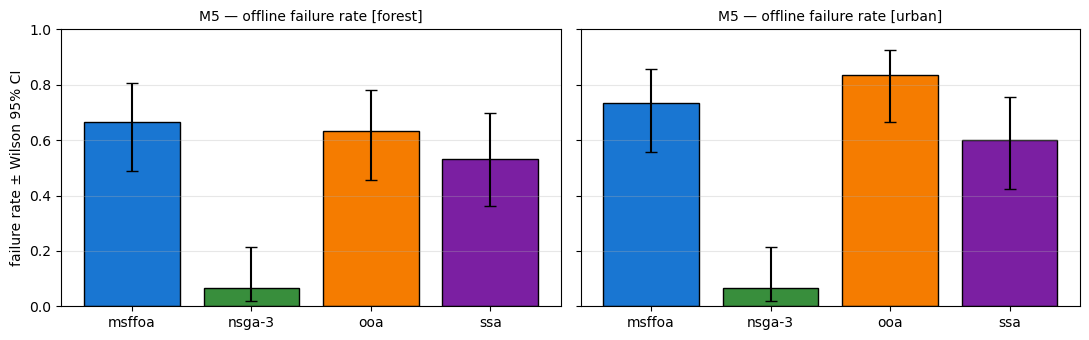

In [12]:
# M5 — odsetek trajektorii kolizyjnych offline (Wilson 95% CI).
print("=" * 80, "\nM5 — Failure rate offline (Wilson 95% CI)")
fail_off = pd.read_csv(STATS_DIR / "wilson" / "failure_rate_offline.csv")
display(fail_off)

# Wizualizacja bar-chart z błędami CI — odpowiednik W1/W2 w `INDEX.md`.
fig, axes = plt.subplots(1, len(ENVIRONMENTS), figsize=(11, 3.5), sharey=True)
for ax, env in zip(axes, ENVIRONMENTS):
    sub = fail_off[fail_off["environment"] == env].sort_values("optimizer")
    pos = np.arange(len(sub))
    err_lo = sub["failure_rate"] - sub["wilson_ci95_low"]
    err_hi = sub["wilson_ci95_high"] - sub["failure_rate"]
    ax.bar(pos, sub["failure_rate"], yerr=[err_lo, err_hi], capsize=4,
           color=["#1976d2", "#388e3c", "#f57c00", "#7b1fa2"][:len(sub)],
           edgecolor="black")
    ax.set_xticks(pos); ax.set_xticklabels(sub["optimizer"], rotation=0)
    ax.set_title(f"M5 — offline failure rate [{env}]", fontsize=10)
    ax.set_ylim(0, 1); ax.grid(True, axis="y", alpha=0.3)
axes[0].set_ylabel("failure rate ± Wilson 95% CI")
plt.tight_layout(); plt.show()

## Notatka metodologiczna

Wszystkie testy są przeprowadzane na lokalnym, samodzielnym subsetcie
(`appendix/A_metrics/run_metrics_subset.csv`, ≈ 240 wierszy = 4 algorytmy ×
2 środowiska × 30 ziaren). Pełna baza analityczna (`analysis.db`) — z której
wygenerowano `appendix/B_statistical_tests/` — zawiera dodatkowe metryki
i kolumny pochodne; pełną listę cytowanych w pracy artefaktów znajdziesz
w `appendix/INDEX.md`.

Wyniki testu Friedmana z tego notebooka powinny zgadzać się z plikami
`appendix/B_statistical_tests/friedman/<env>_friedman_<metric>.csv`
(różnice w 4 cyfrze są tolerowane — wynikają z różnych implementacji
rangowania remisów).

**Nie liczymy** ponownie wszystkich metryk z surowych plików per-run
(`H5/optimization_history.h5`, `convergence_traces.csv`); celem notebooka
jest *weryfikacja* gotowego subsetu, nie duplikacja pipeline'u ETL
(zob. `src/analysis/ETL_TABLES.md`).